# Seaborn Statistical Visualizations: Beginner-Friendly Revision Guide: Beginner Guide

### 🌟 What is Seaborn & Statistical Distribution Plotting?
**Seaborn** is a statistical visualization library built on top of Matplotlib that integrates seamlessly with Pandas. It makes visualizing distributions, kernel density estimates (`histplot`, `kdeplot`), box plots, violin plots, and categorical summaries simple and aesthetically pleasing.

This interactive guide loads and works directly with `data/raw_transactions.csv`, giving you real-world hands-on practice.

### 📚 Key Concepts Covered in this Notebook:
- **Distribution Analysis (`histplot`, `kdeplot`, `ecdfplot`, `rugplot`)**: How to explore data distributions and density curves with zero boilerplate.
- **Categorical Summaries (`boxplot`, `violinplot`, `stripplot`, `swarmplot`, `barplot`)**: How to compare groups, medians, quartiles, and outliers effortlessly.
- **Relational Plotting (`scatterplot`, `lineplot`, `regplot`)**: How to map multi-variable relationships and add linear regression trendlines.


In [1]:
# Step 1: Import all necessary libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Step 2: Set clean visual defaults
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

# Step 3: Load the transactions dataset
csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)

# Step 4: Ensure dates and numeric values are clean
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"✅ Successfully loaded {len(df)} transactions from {csv_path}")
df.head(3)

✅ Successfully loaded 14262 transactions from ../data/raw_transactions.csv


,transaction_id,customer_id,merchant_id,transaction_amount,card_type,transaction_status,device_type,account_age_months,transaction_date,region,is_fraud
0,TX110686,C82845,M2697,1216.33,Visa,Failed,POS,56,2025-07-06 00:00:00,North,0
1,TX107170,C85674,M3868,324.99,MasterCard,Reversed,Desktop,112,2025-10-05 00:00:00,East,0
2,TX108328,C32431,M1461,136.66,Discover,Completed,ATM,68,2025-07-26 06:22:30,East,0


### 🔹 🔹 Distribution Histogram: `sns.histplot()`
Demonstrates how to use `🔹 Distribution Histogram: `sns.histplot()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `# 1. Plot amount distribution with a smooth curve`


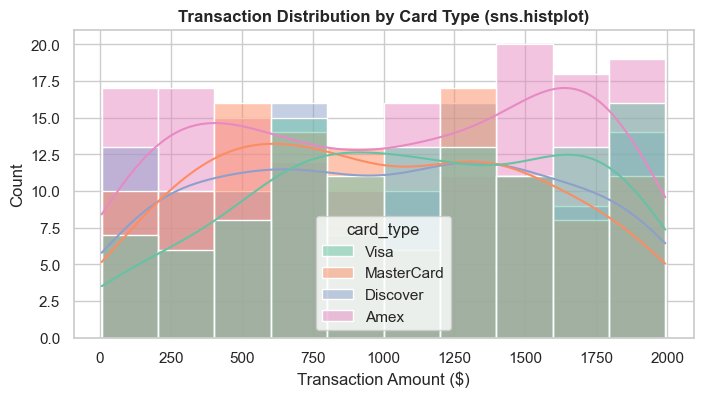

In [2]:
# 1. Plot amount distribution with a smooth curve
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df.head(500), x='transaction_amount', hue='card_type', kde=True, ax=ax, palette='Set2')
ax.set_title('Transaction Distribution by Card Type (sns.histplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)')

plt.show()

### 🔹 🔹 Kernel Density Estimation: `sns.kdeplot()`
Demonstrates how to use `🔹 Kernel Density Estimation: `sns.kdeplot()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `fig, ax = plt.subplots(figsize=(8, 4))`


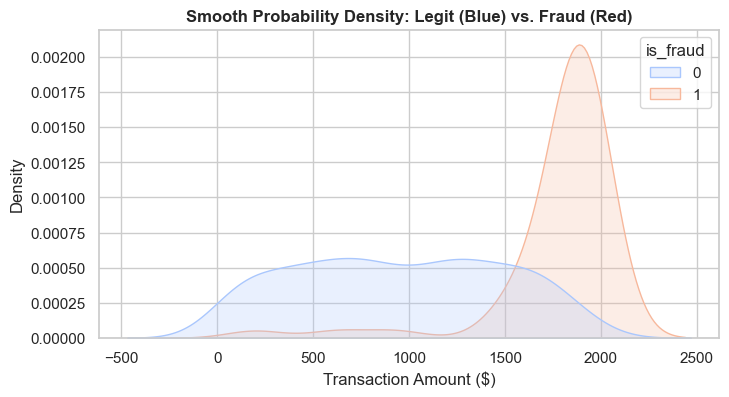

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(df.head(500), x='transaction_amount', hue='is_fraud', fill=True, common_norm=False, palette='coolwarm', ax=ax)
ax.set_title('Smooth Probability Density: Legit (Blue) vs. Fraud (Red)', fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)')

plt.show()

### 🔹 🔹 Boxplots: `sns.boxplot()`
Demonstrates how to use `🔹 Boxplots: `sns.boxplot()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `fig, ax = plt.subplots(figsize=(8, 4.5))`


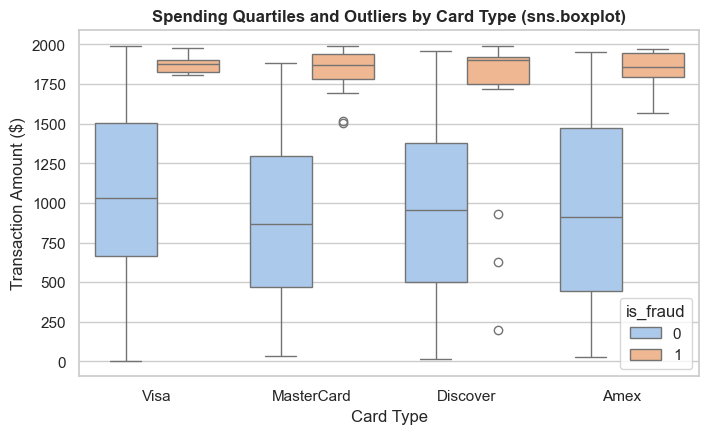

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(df.head(500), x='card_type', y='transaction_amount', hue='is_fraud', palette='pastel', ax=ax)
ax.set_title('Spending Quartiles and Outliers by Card Type (sns.boxplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Card Type')
ax.set_ylabel('Transaction Amount ($)')

plt.show()

### 🔹 🔹 Violin Plots: `sns.violinplot()`
Demonstrates how to use `🔹 Violin Plots: `sns.violinplot()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `fig, ax = plt.subplots(figsize=(8, 4.5))`


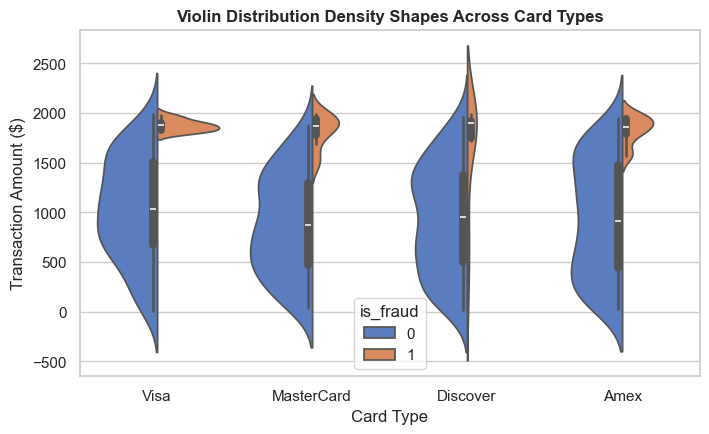

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(df.head(500), x='card_type', y='transaction_amount', hue='is_fraud', split=True, palette='muted', ax=ax)
ax.set_title('Violin Distribution Density Shapes Across Card Types', fontsize=12, fontweight='bold')
ax.set_xlabel('Card Type')
ax.set_ylabel('Transaction Amount ($)')

plt.show()

### 🔹 🔹 Categorical Strip & Swarm Plots: `sns.stripplot()` & `sns.swarmplot()`
Demonstrates how to use `🔹 Categorical Strip & Swarm Plots: `sns.stripplot()` & `sns.swarmplot()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `fig, ax = plt.subplots(figsize=(8, 4))`


C:\Users\DELL\AppData\Local\Temp\ipykernel_9888\3841993190.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(df.head(200), x='region', y='transaction_amount', jitter=0.25, alpha=0.7, palette='tab10', ax=ax)


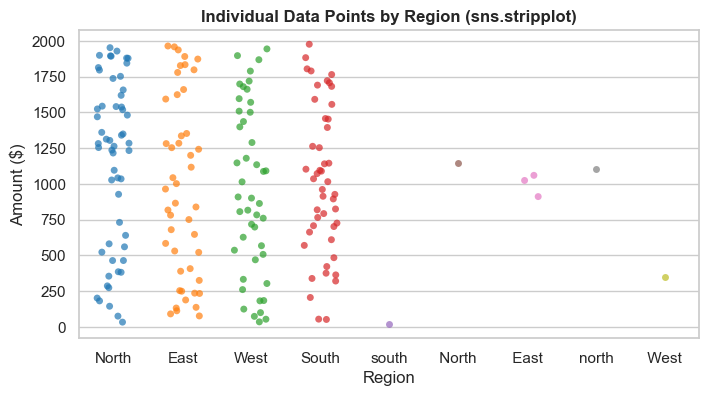

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(df.head(200), x='region', y='transaction_amount', jitter=0.25, alpha=0.7, palette='tab10', ax=ax)
ax.set_title('Individual Data Points by Region (sns.stripplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Amount ($)')

plt.show()

### 🔹 🔹 Bar Plot with 95% Confidence Intervals: `sns.barplot()`
Demonstrates how to use `🔹 Bar Plot with 95% Confidence Intervals: `sns.barplot()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `fig, ax = plt.subplots(figsize=(8, 4.5))`


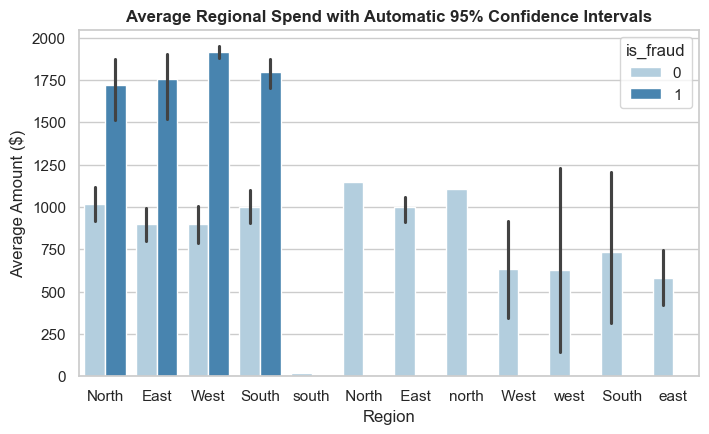

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(df.head(500), x='region', y='transaction_amount', hue='is_fraud', palette='Blues', ax=ax)
ax.set_title('Average Regional Spend with Automatic 95% Confidence Intervals', fontsize=12, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Average Amount ($)')

plt.show()

### 🔹 🔹 Scatter Plot with Multi-Encoding: `sns.scatterplot()`
Demonstrates how to use `🔹 Scatter Plot with Multi-Encoding: `sns.scatterplot()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `fig, ax = plt.subplots(figsize=(8, 4.5))`


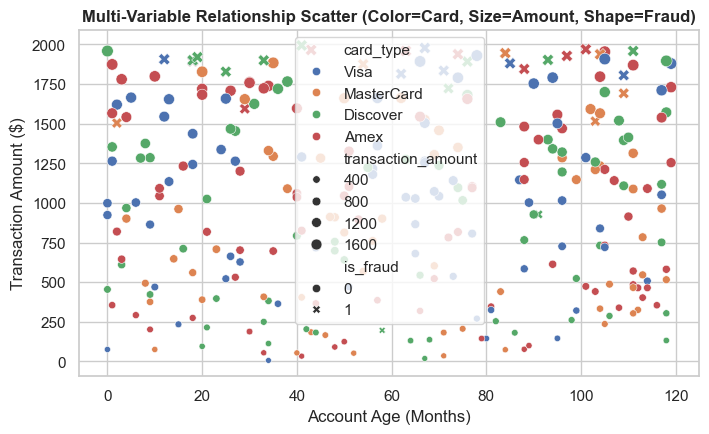

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(
    data=df.head(300), 
    x='account_age_months', 
    y='transaction_amount', 
    hue='card_type', 
    size='transaction_amount', 
    style='is_fraud', 
    ax=ax
)
ax.set_title('Multi-Variable Relationship Scatter (Color=Card, Size=Amount, Shape=Fraud)', fontsize=12, fontweight='bold')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')

plt.show()

### 🔹 🔹 Linear Regression Best-Fit: `sns.regplot()`
Demonstrates how to use `🔹 Linear Regression Best-Fit: `sns.regplot()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `fig, ax = plt.subplots(figsize=(8, 4))`


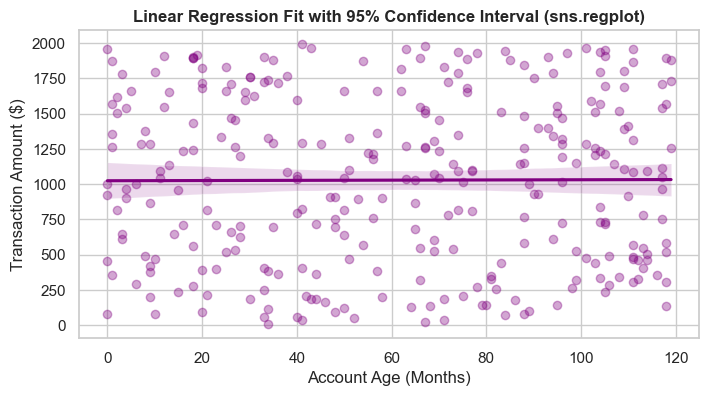

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.regplot(data=df.head(300), x='account_age_months', y='transaction_amount', color='purple', scatter_kws={'alpha':0.35}, ax=ax)
ax.set_title('Linear Regression Fit with 95% Confidence Interval (sns.regplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')

plt.show()